In [1]:
import sys
import os
from scipy import stats

# Get the absolute path of the parent directory
parent_dir = os.path.abspath('..')

# Add it to the system path if it isn't already there
if parent_dir not in sys.path:
    sys.path.append(parent_dir)


import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt


# 1. Fetch the dataset
california = fetch_california_housing(as_frame=True)

# 2. Extract MedInc as the single input feature (X)
# We keep it as a DataFrame (using double brackets) so it retains its column name and 2D shape
X = california.frame[["MedInc"]]

# 3. Extract the median house value as the target (y)
y = california.target

# Optional: Quick check to see what the data looks like
print("Feature (X) preview:")
print(X.head())
print("\nTarget (y) preview:")
print(y.head())

Feature (X) preview:
   MedInc
0  8.3252
1  8.3014
2  7.2574
3  5.6431
4  3.8462

Target (y) preview:
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


In [2]:
california

{'data':        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
 1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
 2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
 3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
 4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
 ...       ...       ...       ...        ...         ...       ...       ...   
 20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
 20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
 20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
 20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
 20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   
 
        Longitude 

In [3]:
# 1. Extract MedInc column as a 2D DataFrame for X
X = california['data'][['MedInc']]

# 2. Extract the target values for y
y = california['target']

# 3. Print to verify they loaded perfectly
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 1)
y shape: (20640,)


In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    train_size=100, 
    test_size=100, 
    random_state=42
)

# Convert features to 1D numpy arrays to make the polynomial math much easier
x_train_arr = X_train["MedInc"].values
x_val_arr = X_val["MedInc"].values

# Convert targets to numpy arrays as well
y_train_arr = y_train.values
y_val_arr = y_val.values

In [6]:
# ==========================================
# PART 4.1.1: OLS SANITY CHECK
# ==========================================
import numpy as np
from sklearn.linear_model import LinearRegression as SklearnLR
from src.linear_regression import LinearRegression as CustomLR

print("--- Running Sanity Check for OLS ---")

# 1. Create a random test matrix and target vector
np.random.seed(42)
X_random = np.random.rand(100, 5) 
y_random = 3 * X_random[:, 0] + 1.5 * X_random[:, 2] - 2 * X_random[:, 4] + np.random.randn(100) * 0.1

# 2. Fit Scikit-Learn's model
# Assuming your custom model expects you to add the intercept manually or handles it inherently.
# We set fit_intercept=True to match standard behavior.
sk_model = SklearnLR(fit_intercept=True)
sk_model.fit(X_random, y_random)
sk_preds = sk_model.predict(X_random)

# 3. Fit YOUR custom model
my_model = CustomLR()
# Note: If your custom model requires a column of 1s manually, add it to X_random here first!
my_model.fit(X_random, y_random)
my_preds = my_model.predict(X_random)

# 4. Compare outputs within 10^-9
# np.allclose is the perfect NumPy function for this tolerance check
is_match = np.allclose(sk_preds, my_preds, atol=1e-9)

print(f"Outputs match within 10^-9: {is_match}")
if is_match:
    print("Sanity check passed! Custom OLS is mathematically identical to sklearn.")
else:
    print("Sanity check failed. Check your matrix inversion math in src!")

--- Running Sanity Check for OLS ---
Outputs match within 10^-9: True
Sanity check passed! Custom OLS is mathematically identical to sklearn.


Learning Rate 0.001 converged in 1000 iterations.
Learning Rate 0.01 converged in 823 iterations.
Learning Rate 0.1 converged in 90 iterations.


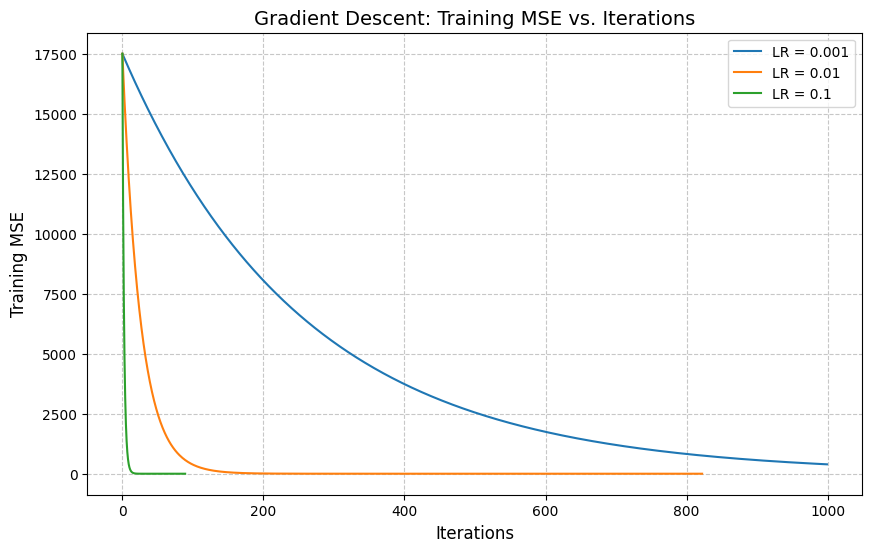


--- Weight Comparison (GD vs OLS) ---
Do the GD weights (LR=0.1) match OLS weights within 10^-4? True
Success! Gradient Descent converged to the exact same global minimum as OLS.


<Figure size 640x480 with 0 Axes>

In [14]:
# ==========================================
# PART 4.1.2: GRADIENT DESCENT EXPERIMENTS
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_regression
from src.linear_regression import LinearRegression as CustomLR
from src.linear_regression_gd import LinearRegressionGD 


# 1. Create synthetic dataset (N=1000, p=10, seed=42)
X_syn, y_syn = make_regression(n_samples=1000, n_features=10, noise=0.5, random_state=42)

# List of learning rates to test
learning_rates = [0.001, 0.01, 0.1]
gd_models = {}

plt.figure(figsize=(10, 6))

# 2. Train and Plot for each learning rate
for current_lr in learning_rates:
    # Initialize your GD model. 
    # CHANGED: 'learning_rate' to 'lr' to match your __init__
    model_gd = LinearRegressionGD(lr=current_lr) 
    
    # Fit the model
    model_gd.fit(X_syn, y_syn)
    gd_models[current_lr] = model_gd
    
    # Plot the loss history
    plt.plot(model_gd.loss_history, label=f'LR = {current_lr}')
    
    # Report iterations
    print(f"Learning Rate {current_lr} converged in {len(model_gd.loss_history)} iterations.")

# 3. Format the Plot
plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Training MSE', fontsize=12)
plt.title('Gradient Descent: Training MSE vs. Iterations', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
plt.savefig('../figures/Gradient Descent: Training MSE vs. Iterations.pdf', format='pdf', dpi=300, bbox_inches='tight')
# ==========================================
# COMPARE FINAL WEIGHTS WITH OLS
# ==========================================
print("\n--- Weight Comparison (GD vs OLS) ---")

# Train closed-form OLS on the same synthetic data
ols_model = CustomLR()
ols_model.fit(X_syn, y_syn)

# We will compare the best GD model (LR=0.1) against OLS.
best_gd_model = gd_models[0.1]
weights_match = np.allclose(best_gd_model.w_weights, ols_model.weights, atol=1e-4)

print(f"Do the GD weights (LR=0.1) match OLS weights within 10^-4? {weights_match}")
if weights_match:
    print("Success! Gradient Descent converged to the exact same global minimum as OLS.")
else:
    print("Failed: Weights did not match perfectly. Double check your gradient math!")

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from src.linear_regression import LinearRegression

# Lists to store your MSE results for plotting later
train_mse_list = []
val_mse_list = []

degrees = range(1, 13) # d in {1, 2, ..., 12}

for d in degrees:
    # --- Feature Engineering ---
    # Construct the polynomial design matrix using list comprehension
    # This creates a matrix of [x^1, x^2, ..., x^d]
    X_train_poly = np.column_stack([x_train_arr**i for i in range(1, d + 1)])
    X_val_poly = np.column_stack([x_val_arr**i for i in range(1, d + 1)])
    
    # --- Standardization ---
    # Subtract mean and divide by std deviation to handle massive numbers
    scaler = StandardScaler()
    
    # FIT the scaler ONLY on the training data to avoid data leakage, 
    # then transform both training and validation sets.
    X_train_scaled = scaler.fit_transform(X_train_poly)
    X_val_scaled = scaler.transform(X_val_poly)
    
    # --- Fitting ---
    # Initialize YOUR custom model (replace with your actual class name if different)
    model = LinearRegression() 
    model.fit(X_train_scaled, y_train_arr)
    
    # --- Evaluation ---
    # Predict on both sets
    y_train_pred = model.predict(X_train_scaled)
    y_val_pred = model.predict(X_val_scaled)
    
    # Calculate Mean Squared Error
    mse_train = mean_squared_error(y_train_arr, y_train_pred)
    mse_val = mean_squared_error(y_val_arr, y_val_pred)
    
    # Store the results
    train_mse_list.append(mse_train)
    val_mse_list.append(mse_val)

print("Experiment loop complete! MSE values successfully stored.")

Experiment loop complete! MSE values successfully stored.


In [12]:
print(train_mse_list)
print(val_mse_list)

[0.6425542440376446, 0.6125081664317755, 0.6121250577105978, 0.599346675646922, 0.5967329316683174, 0.586329632678207, 0.5757119029711526, 0.5514246815998346, 0.5508030469534086, 0.5507709108022144, 0.5489867541277578, 0.5480642163770535]
[0.7662958469219403, 0.7624425654751513, 0.7663375653691109, 0.7572854560145978, 0.7629947414995022, 0.7768353128137748, 0.7543216502884195, 0.7456596421358168, 0.7500472315928005, 0.7502692955660464, 0.7516150447921077, 0.7508676878857632]


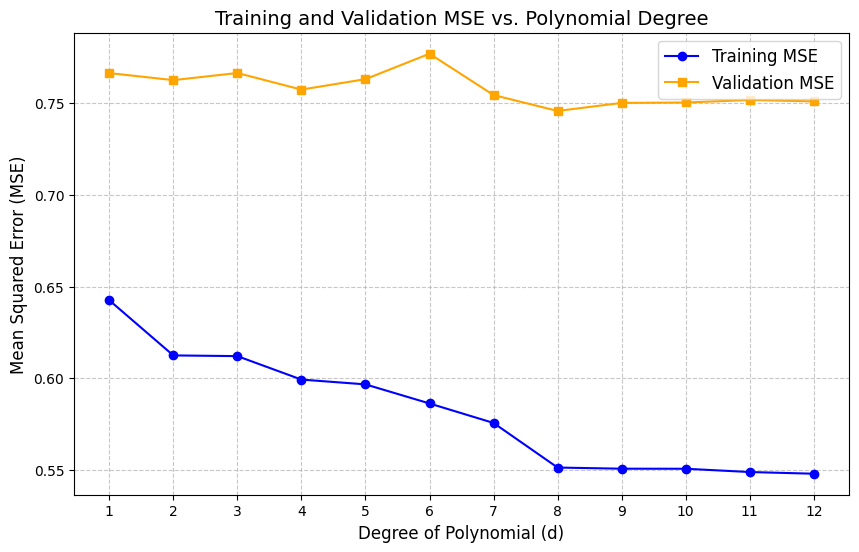

--- Results ---
The degree with the lowest validation MSE is: d = 8
The lowest validation MSE achieved is: 0.7457


<Figure size 640x480 with 0 Axes>

In [13]:

plt.figure(figsize=(10, 6))

# Plot the lines
plt.plot(degrees, train_mse_list, label='Training MSE', marker='o', color='blue')
plt.plot(degrees, val_mse_list, label='Validation MSE', marker='s', color='orange')

# Add required axis labels (crucial for your rubric!)
plt.xlabel('Degree of Polynomial (d)', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('Training and Validation MSE vs. Polynomial Degree', fontsize=14)

# Formatting to make it look clean
plt.xticks(degrees) # Forces the x-axis to show every integer from 1 to 12
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.show()
plt.savefig('../figures/Training and Validation MSE vs. Polynomial Degree.pdf', format='pdf', dpi=300, bbox_inches='tight')

# --- 2. Report the degree with the lowest validation MSE ---
# Find the index of the minimum value in the validation MSE list
best_index = np.argmin(val_mse_list)
best_d = degrees[best_index]
lowest_val_mse = val_mse_list[best_index]

print(f"--- Results ---")
print(f"The degree with the lowest validation MSE is: d = {best_d}")
print(f"The lowest validation MSE achieved is: {lowest_val_mse:.4f}")

In [8]:
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler
# Assuming LinearRegression is imported

# ==========================================
# SETUP EXACT DATA FOR d=5
# ==========================================
d = 5

# 1. Recreate features
X_train_poly = np.column_stack([x_train_arr**i for i in range(1, d + 1)])
X_val_poly = np.column_stack([x_val_arr**i for i in range(1, d + 1)])

# 2. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_val_scaled = scaler.transform(X_val_poly)

# 3. Retrain the d=5 model 
model_d5 = LinearRegression()
model_d5.fit(X_train_scaled, y_train_arr)

# ==========================================
# PREDICTION INTERVAL MATH
# ==========================================
# Create the full "Design Matrix" by adding a column of 1s for the intercept
# This is required for the (X^T X)^-1 math to work correctly
X_train_design = np.column_stack([np.ones(len(X_train_scaled)), X_train_scaled])
X_val_design = np.column_stack([np.ones(len(X_val_scaled)), X_val_scaled])

N = X_train_design.shape[0]
p = X_train_design.shape[1] # Now includes the intercept column!

# 1. Estimate noise variance 
y_train_pred = model_d5.predict(X_train_scaled)
# Use y_train_arr (numpy array) instead of y_train (DataFrame) to prevent index alignment bugs
sigma_squared = (1 / (N - p)) * np.sum((y_train_arr - y_train_pred)**2)

# 2. Pre-calculate the inverse term (X^T X)^-1 using the design matrix
XTX_inv = np.linalg.inv(X_train_design.T @ X_train_design)

# Get the t-statistic
t_val = stats.t.ppf(0.975, df=N-p)

# 3. Calculate intervals
lower_bounds = []
upper_bounds = []
y_val_pred = model_d5.predict(X_val_scaled)

for i in range(len(X_val_design)):
    # x_star is now a single 1D numpy array extracted from the validation design matrix
    x_star = X_val_design[i] 
    
    leverage = x_star.T @ XTX_inv @ x_star
    margin_of_error = t_val * np.sqrt(sigma_squared * (1 + leverage))
    
    prediction = y_val_pred[i]
    lower_bounds.append(prediction - margin_of_error)
    upper_bounds.append(prediction + margin_of_error)

print("d=5 prediction bounds calculated successfully!")

# You can now plot: x_val_arr (True X), y_val_arr (True Y), y_val_pred (Model Line), 
# and your lower_bounds/upper_bounds!

d=5 prediction bounds calculated successfully!


<>:33: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:33: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
C:\Users\Emil\AppData\Local\Temp\ipykernel_5392\3415913701.py:33: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  plt.ylabel('Predicted Validation Values ($\hat{y}$)', fontsize=12)


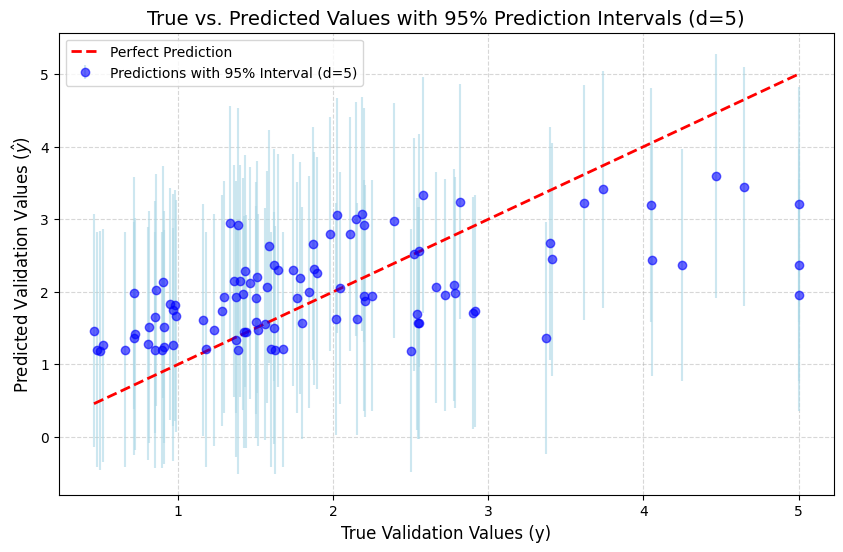

In [9]:
import matplotlib.pyplot as plt

# 1. Convert lists to numpy arrays for easier math
y_val_pred = np.array(y_val_pred)
upper_bounds = np.array(upper_bounds)

# 2. Calculate the exact margin of error for the error bars (distance from prediction to bound)
error_bars = upper_bounds - y_val_pred

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plot True y vs Predicted y_hat with the prediction intervals as error bars
plt.errorbar(
    y_val_arr,           # X-axis: True validation values
    y_val_pred,          # Y-axis: Predicted validation values
    yerr=error_bars,     # Vertical error bars for the 95% interval
    fmt='o',             # 'o' makes it a scatter plot
    color='blue', 
    ecolor='lightblue',  # Lighter color for the error bars so it isn't too messy
    alpha=0.6, 
    label='Predictions with 95% Interval (d=5)'
)

# 4. Add the "Perfect Prediction" reference line (y = x)
# If the model was 100% accurate, every dot would fall perfectly on this line
min_val = np.min(y_val_arr)
max_val = np.max(y_val_arr)
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

# 5. Formatting (Crucial for your rubric!)
plt.xlabel('True Validation Values (y)', fontsize=12)
plt.ylabel('Predicted Validation Values ($\hat{y}$)', fontsize=12)
plt.title('True vs. Predicted Values with 95% Prediction Intervals (d=5)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()